<a href="https://colab.research.google.com/github/nieblasIX/IX-Pachuca-RESISTENCIATUZA/blob/main/ResistenciaTuzaPachuca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cartografía de lo Invisible: Resistencia de la Tuza en Pachuca**

Cambiar la mirada de la tuza
un animal históricamente desplazado y visto como plaga para convertirlo en un indicador de justicia espacial y de memoria histórica en Pachuca es un ejercicio de Filosofía de la Liberación aplicada a la ecología. Pachuca es una ciudad construida sobre túneles mineros de extracción humana; las tuzas construyen túneles para la regeneración del suelo. Es una perfecta ironía poética y espacial.

**Planteamiento Ecológico y de Liberación: El Ingeniero del Suelo**

Ecológicamente, los geómidos como las tuzas(Cratogeomys spp.) no son plagas, son ingenieros del ecosistema. Remueven el suelo, permiten la aireación, aumentan la infiltración de agua y entierran materia orgánica. Su exterminio en Pachuca no es un accidente biológico, sino el resultado de un modelo urbanístico que valora el suelo sólo como superficie de tránsito o construcción, ignorando el volumen biológico del subsuelo.

**El Conflicto:** La tuza requiere suelos profundos, aireados y con cobertura vegetal (raíces/bulbos). La urbanización impone sellado asfáltico y compactación, lo que equivale a la "desaparición" de su mundo tridimensional.

**La Perspectiva de la Liberación:** Siguiendo a Dussel, situamos a la tuza como el "Sujeto Oprimido" del ecosistema urbano. Su "plaga" es, en realidad, un acto de presencia frente al despojo de su hábitat histórico por la lógica del capital minero y ahora inmobiliario.

 La tuza representa a la Alteridad oprimida por la totalidad del sistema urbano-industrial. Mapear su hábitat no es solo un ejercicio técnico, es un acto de justicia interespecie: visibilizar al que el sistema ha decidido ignorar y destruir.

**Variables Satelitales Clave**

Para un análisis de series de tiempo (pensemos en una escala de 20 a 30 años con Landsat 5, 7, 8 y 9, complementado con Sentinel-2), las variables deben medir tres cosas: *comida (vegetación), casa (suelo) y amenaza (urbanización).*
1. **Dinámica de la Vegetación (Alimento y Cobertura)**
NDVI / EVI: Tendencias anuales y estacionales. Las tuzas prefieren pastizales y zonas de matorral con raíces palatables. Un análisis armónico de NDVI en GEE te dirá si la fenología del paisaje ha cambiado.
2. **Estado del Suelo
(El Medio Físico)**: BSI (Bare Soil Index) Para identificar zonas de suelo desnudo o degradado por la expansión minera y urbana; asi como un Índice de Humedad de Diferencia Normalizada (NDMI). Las tuzas evitan suelos saturados de agua (se ahogan) pero necesitan suelo que no sea roca pura para excavar.
3. **La Huella Antrópica(La Opresión)** con
LST (Land Surface Temperature): Las islas de calor urbanas degradan el microclima del suelo. También el NDBI (Índice de Edificación) / Luces Nocturnas (VIIRS/DMSP)que servirán para mapear el crecimiento de la mancha urbana que fragmenta el territorio año con año.
4. **Topografía y termodinámica (El Escenario)**: Usando el MDE (modelo digital de elevación SRTM o NASADEM) para encontrar pendientes y orientación. Las tuzas prefieren pendientes suaves donde el drenaje del suelo sea eficiente. Asímismo, las tuzas son sensibles al estrés térmico. El efecto "Isla de Calor" en Pachuca limita sus corredores que se observaría con el cálculo de LST (Land Surface Temperature).

**Análisis Temporal: La Crónica del Despojo**

Proponemos un análisis de tres nodos temporales (e.g., 1990, 2000, 2012-2026):

**Detección de Cambio de Cobertura**(LULC): Cuantificar cuántas hectáreas de suelo apto han sido "selladas".

**Análisis de Fragmentación:** Utilizar métricas de ecología del paisaje (a través de Python/Geemap) para calcular el aislamiento de las poblaciones de tuzas en "islas" urbanas (baldíos, camellones, campos de fútbol).

**Construcción del Modelo de Hábitat de la Tuza**

Para modelar el hábitat sin caer en determinismos absurdos, podemos construir un Índice de Idoneidad de Hábitat (HSI) o correr un modelo de clasificación automática (Random Forest) basado en presencia-pseudoausencia.
El Índice de Idoneidad de Hábitat (HSI) será nuestra herramienta de denuncia. No es solo un mapa de probabilidad, es un mapa de derecho al territorio.



In [63]:
# CARTOGRAFÍA DE LO INVISIBLE: RESISTENCIA DE LA TUZA EN PACHUCA
# Análisis Espacial multitemporal (1990 - 2026)
# ==============================================================================

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# 1. AUTENTICACIÓN E INICIALIZACIÓN
# ------------------------------------------------------------------------------
try:
    ee.Initialize(project='resistenciatuza')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='resistenciatuza')

# Inicializar el mapa interactivo principal
Map = geemap.Map()

In [64]:
# ------------------------------------------------------------------------------
# 2. DEFINICIÓN DEL TERRITORIO Y TOPOGRAFÍA
# ------------------------------------------------------------------------------
print("☑️ Configurando la región de estudio...")
default_lon = -98.7692  # Longitud aproximada de Pachuca
default_lat = 20.1066   # Latitud aproximada de Pachuca
pachuca = ee.Geometry.Point(default_lon, default_lat).buffer(10000) # Buffer de 10 km

# Centrar el mapa principal
Map.centerObject(pachuca, 12)
Map.addLayer(pachuca, {'color': 'black'}, 'Límite Geométrico Pachuca', False, 0.5)

# Topografía (SRTM 30m)
srtm = ee.Image('USGS/SRTMGL1_003')
elevacion = srtm.select('elevation').clip(pachuca)
pendiente = ee.Terrain.slope(elevacion).clip(pachuca)

Map.addLayer(elevacion, {'min': 2300, 'max': 3000, 'palette': ['green', 'yellow', 'brown', 'white']}, 'Elevación')
Map.addLayer(pendiente, {'min': 0, 'max': 45, 'palette': ['white', 'black']}, 'Pendiente', False)

# Exportar la geometría a los Assets de GEE
if isinstance(pachuca, ee.geometry.Geometry):
    feature_to_export = ee.FeatureCollection([ee.Feature(pachuca)])
else:
    feature_to_export = pachuca

task_geom = ee.batch.Export.table.toAsset(
    collection=feature_to_export,
    description='Pachuca_Geometry_Export',
    assetId='users/resistenciatuza/Pachuca_Geometry'
)
task_geom.start()
print(f'☑️ Exportación de geometría a Asset iniciada (Tarea: {task_geom.id})')

☑️ Configurando la región de estudio...
☑️ Exportación de geometría a Asset iniciada (Tarea: TQHBXEMR37E2YN42NQN2DAQU)


In [65]:
# ------------------------------------------------------------------------------
# 3. FUNCIONES MULTITEMPORALES (LST, ALBEDO, ÍNDICES)
# ------------------------------------------------------------------------------
def get_l5_1990():
    """Procesa Landsat 5 para 1990"""
    col = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2") \
        .filterBounds(pachuca).filterDate('1989-01-01', '1991-12-31') \
        .filter(ee.Filter.lt('CLOUD_COVER', 10)).median().clip(pachuca)

    lst = col.select('ST_B6').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
    albedo = col.expression(
        '(0.356 * B1) + (0.130 * B3) + (0.373 * B4) + (0.085 * B5) + (0.072 * B7) - 0.0018', {
            'B1': col.select('SR_B1').multiply(0.0000275).add(-0.2),
            'B3': col.select('SR_B3').multiply(0.0000275).add(-0.2),
            'B4': col.select('SR_B4').multiply(0.0000275).add(-0.2),
            'B5': col.select('SR_B5').multiply(0.0000275).add(-0.2),
            'B7': col.select('SR_B7').multiply(0.0000275).add(-0.2)
    }).rename('Albedo')
    ndbi = col.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDBI')
    ndvi = col.normalizedDifference(['SR_B4', 'SR_B3']).rename('NDVI')
    bsi = col.expression('((B5 + B3) - (B4 + B1)) / ((B5 + B3) + (B4 + B1))',
        {'B5': col.select('SR_B5'), 'B3': col.select('SR_B3'), 'B4': col.select('SR_B4'), 'B1': col.select('SR_B1')}
    ).rename('BSI')

    return ee.Image([lst, albedo, ndbi, ndvi, bsi])

def get_l8_2026():
    """Procesa Landsat 8/9 para 2026"""
    col = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
        .filterBounds(pachuca).filterDate('2025-01-01', '2026-03-01') \
        .filter(ee.Filter.lt('CLOUD_COVER', 10)).median().clip(pachuca)

    lst = col.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
    albedo = col.expression(
        '(0.356 * B2) + (0.130 * B4) + (0.373 * B5) + (0.085 * B6) + (0.072 * B7) - 0.0018', {
            'B2': col.select('SR_B2').multiply(0.0000275).add(-0.2),
            'B4': col.select('SR_B4').multiply(0.0000275).add(-0.2),
            'B5': col.select('SR_B5').multiply(0.0000275).add(-0.2),
            'B6': col.select('SR_B6').multiply(0.0000275).add(-0.2),
            'B7': col.select('SR_B7').multiply(0.0000275).add(-0.2)
    }).rename('Albedo')
    ndbi = col.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
    ndvi = col.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    bsi = col.expression('((B6 + B4) - (B5 + B2)) / ((B6 + B4) + (B5 + B2))',
        {'B6': col.select('SR_B6'), 'B4': col.select('SR_B4'), 'B5': col.select('SR_B5'), 'B2': col.select('SR_B2')}
    ).rename('BSI')

    return ee.Image([lst, albedo, ndbi, ndvi, bsi])

img_1990 = get_l5_1990()
img_2026 = get_l8_2026()

# Añadir Islas de Calor (Violencia Térmica)
vis_lst = {'min': 15, 'max': 40, 'palette': ['blue', 'green', 'yellow', 'orange', 'red']}
Map.addLayer(img_1990.select('LST'), vis_lst, 'Temperatura (LST) 1990', False)
Map.addLayer(img_2026.select('LST'), vis_lst, 'Temperatura (LST) 2026', False)

# Diferencia de LST (Violencia Acumulada)
lst_diff = img_2026.select('LST').subtract(img_1990.select('LST')).rename('LST_Difference')
vis_lst_diff = {'min': -10, 'max': 10, 'palette': ['blue', 'cyan', 'green', 'yellow', 'red']}
Map.addLayer(lst_diff, vis_lst_diff, 'Diferencia LST (2026 - 1990)')

# Exportar LST Difference a Drive
task_export_lst_diff = ee.batch.Export.image.toDrive(
    image=lst_diff,
    description='LST_Difference_Pachuca',
    folder='EarthEngine_Exports',
    region=pachuca.bounds(),
    scale=30,
    crs='EPSG:4326',
    fileFormat='GeoTIFF'
)
task_export_lst_diff.start()
print(f'☑️ Exportación LST_diff a Drive iniciada (Tarea: {task_export_lst_diff.id})')

☑️ Exportación LST_diff a Drive iniciada (Tarea: T6DH6DMIITH4JKFULESF4FVH)


In [66]:
# ------------------------------------------------------------------------------
# 4. DETECCIÓN DE CAMBIO DE COBERTURA (LULC - K-MEANS)
# ------------------------------------------------------------------------------
print("☑️ Entrenando clasificación K-Means para LULC...")
training_1990 = img_1990.sample(region=pachuca, scale=30, numPixels=5000)
clusterer_1990 = ee.Clusterer.wekaKMeans(3).train(training_1990)
lulc_1990 = img_1990.cluster(clusterer_1990).rename('LULC')

training_2026 = img_2026.sample(region=pachuca, scale=30, numPixels=5000)
clusterer_2026 = ee.Clusterer.wekaKMeans(3).train(training_2026)
lulc_2026 = img_2026.cluster(clusterer_2026).rename('LULC')

Map.addLayer(lulc_1990.randomVisualizer(), {}, 'LULC Clusters 1990', False)
Map.addLayer(lulc_2026.randomVisualizer(), {}, 'LULC Clusters 2026', False)

☑️ Entrenando clasificación K-Means para LULC...


In [67]:
# ------------------------------------------------------------------------------
# 5. EXTRACCIÓN DE DATOS Y ESTADÍSTICA (PANDAS)
# ------------------------------------------------------------------------------
print("☑️ Extrayendo valores de píxeles para análisis estadístico (esto puede tomar unos segundos)...")

# Promedio de LST Diferencia
mean_lst_diff = lst_diff.reduceRegion(reducer=ee.Reducer.mean(), geometry=pachuca, scale=30, maxPixels=1e9)
mean_value = mean_lst_diff.get('LST_Difference').getInfo()

# Extracción de listas de píxeles
ndvi_1990_values = img_1990.select('NDVI').reduceRegion(reducer=ee.Reducer.toList(), geometry=pachuca, scale=30, maxPixels=1e9).get('NDVI').getInfo()
ndvi_2026_values = img_2026.select('NDVI').reduceRegion(reducer=ee.Reducer.toList(), geometry=pachuca, scale=30, maxPixels=1e9).get('NDVI').getInfo()
lst_diff_values = lst_diff.reduceRegion(reducer=ee.Reducer.toList(), geometry=pachuca, scale=30, maxPixels=1e9).get('LST_Difference').getInfo()

# DataFrames
df_ndvi_1990 = pd.DataFrame(ndvi_1990_values, columns=['NDVI'])
df_ndvi_2026 = pd.DataFrame(ndvi_2026_values, columns=['NDVI'])
df_lst_diff = pd.DataFrame(lst_diff_values, columns=['LST_Difference'])

# Cálculos de promedios
mean_ndvi_1990 = df_ndvi_1990['NDVI'].mean()
mean_ndvi_2026 = df_ndvi_2026['NDVI'].mean()
ndvi_mean_difference = mean_ndvi_2026 - mean_ndvi_1990

print(f'\n--- RESULTADOS ESTADÍSTICOS ---')
print(f'Promedio de cambio térmico (LST diff): {mean_value:.2f} °C')
print(f'Promedio NDVI 1990: {mean_ndvi_1990:.4f}')
print(f'Promedio NDVI 2026: {mean_ndvi_2026:.4f}')
print(f'Diferencia NDVI (2026 - 1990): {ndvi_mean_difference:.4f}')

# Correlación (Asegurando misma longitud de arrays para evitar crasheos de Pandas)
min_len = min(len(df_lst_diff), len(df_ndvi_2026))
merged_df = pd.DataFrame({
    'LST_Difference': df_lst_diff['LST_Difference'].iloc[:min_len].values,
    'NDVI_2026': df_ndvi_2026['NDVI'].iloc[:min_len].values
})

pearson_corr = merged_df['LST_Difference'].corr(merged_df['NDVI_2026'])
spearman_corr = merged_df['LST_Difference'].corr(merged_df['NDVI_2026'], method='spearman')

print(f'Correlación Pearson (LST diff vs NDVI 2026): {pearson_corr:.4f}')
print(f'Correlación Spearman (LST diff vs NDVI 2026): {spearman_corr:.4f}\n')

☑️ Extrayendo valores de píxeles para análisis estadístico (esto puede tomar unos segundos)...

--- RESULTADOS ESTADÍSTICOS ---
Promedio de cambio térmico (LST diff): 5.09 °C
Promedio NDVI 1990: 0.1416
Promedio NDVI 2026: 0.1371
Diferencia NDVI (2026 - 1990): -0.0044
Correlación Pearson (LST diff vs NDVI 2026): -0.2599
Correlación Spearman (LST diff vs NDVI 2026): -0.2740



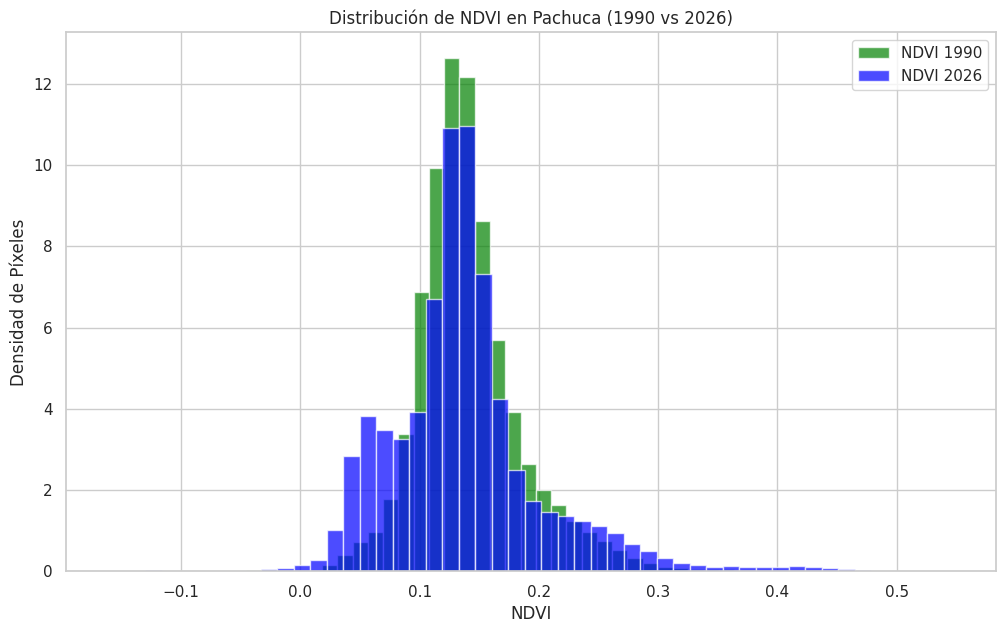

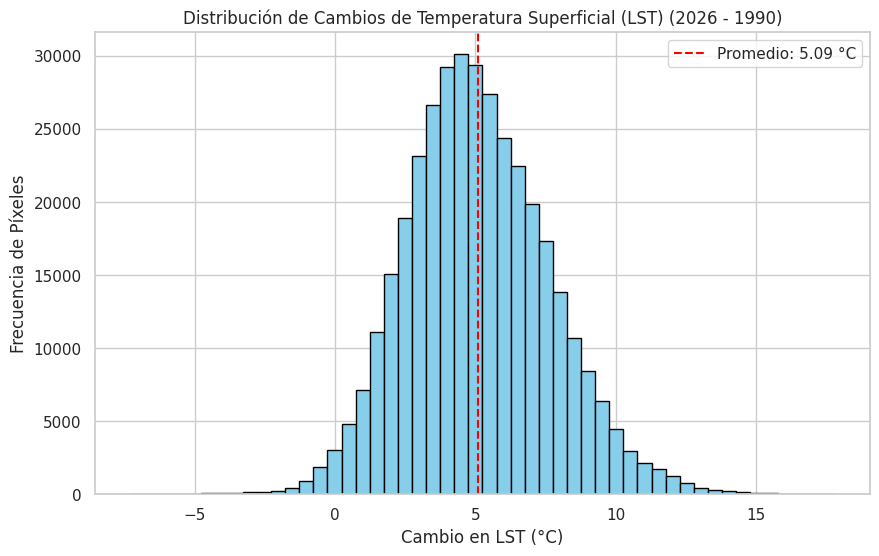

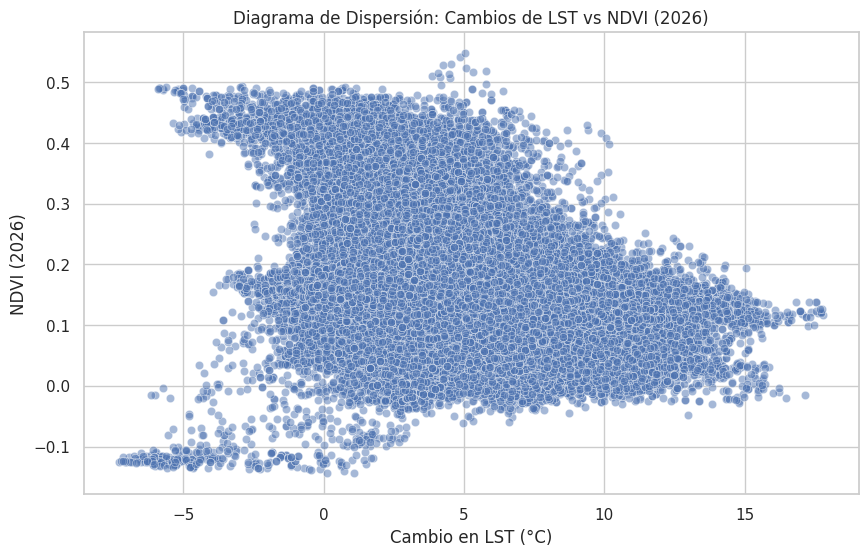

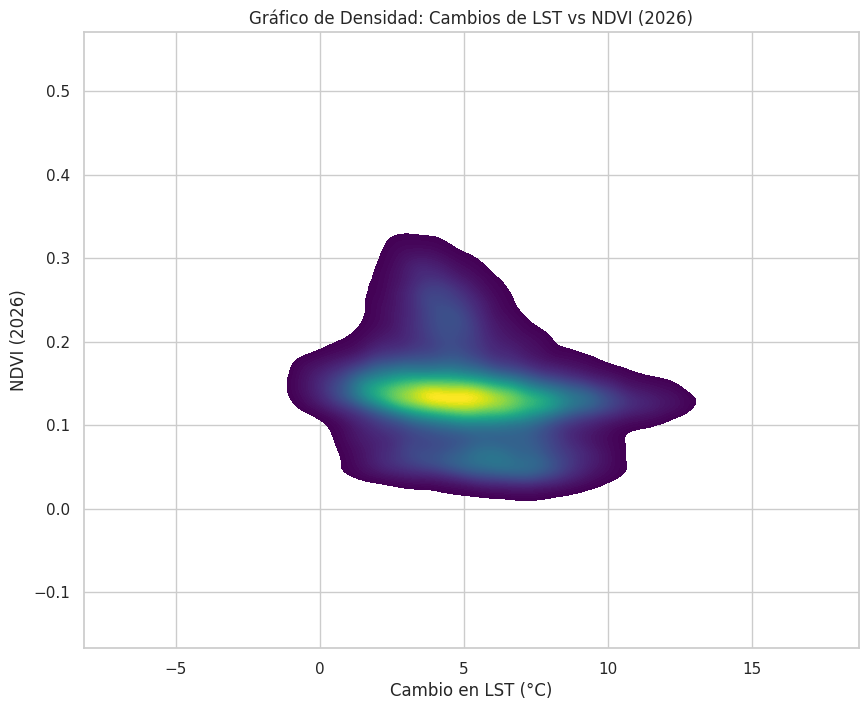

In [68]:
# ------------------------------------------------------------------------------
# 6. VISUALIZACIÓN GRÁFICA (MATPLOTLIB & SEABORN)
# ------------------------------------------------------------------------------
sns.set_theme(style="whitegrid")

# Figura 1: Histogramas NDVI
plt.figure(figsize=(12, 7))
plt.hist(df_ndvi_1990['NDVI'], bins=50, alpha=0.7, label='NDVI 1990', color='green', density=True)
plt.hist(df_ndvi_2026['NDVI'], bins=50, alpha=0.7, label='NDVI 2026', color='blue', density=True)
plt.title('Distribución de NDVI en Pachuca (1990 vs 2026)')
plt.xlabel('NDVI')
plt.ylabel('Densidad de Píxeles')
plt.legend()
plt.show()

# Figura 2: Histograma de LST Difference
plt.figure(figsize=(10, 6))
plt.hist(df_lst_diff['LST_Difference'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Cambios de Temperatura Superficial (LST) (2026 - 1990)')
plt.xlabel('Cambio en LST (°C)')
plt.ylabel('Frecuencia de Píxeles')
plt.axvline(x=mean_value, color='red', linestyle='--', label=f'Promedio: {mean_value:.2f} °C')
plt.legend()
plt.show()

# Figura 3: Dispersión LST vs NDVI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LST_Difference', y='NDVI_2026', data=merged_df, alpha=0.5)
plt.title('Diagrama de Dispersión: Cambios de LST vs NDVI (2026)')
plt.xlabel('Cambio en LST (°C)')
plt.ylabel('NDVI (2026)')
plt.show()

# Figura 4: Densidad LST vs NDVI
plt.figure(figsize=(10, 8))
sns.kdeplot(x=merged_df['LST_Difference'], y=merged_df['NDVI_2026'], cmap='viridis', fill=True, levels=100)
plt.title('Gráfico de Densidad: Cambios de LST vs NDVI (2026)')
plt.xlabel('Cambio en LST (°C)')
plt.ylabel('NDVI (2026)')
plt.show()

In [ ]:
# ------------------------------------------------------------------------------
# 7. MAPAS VINCULADOS DE COMPARACIÓN E IMPRESIÓN DEL MAPA PRINCIPAL
# ------------------------------------------------------------------------------
print("☑️ Generando mapas comparativos interactivos...")

left_map = geemap.Map()
right_map = geemap.Map()
left_map.centerObject(pachuca, 12)
right_map.centerObject(pachuca, 12)

vis_ndvi = {'min': 0, 'max': 0.5, 'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']}
left_map.addLayer(img_1990.select('NDVI'), vis_ndvi, 'NDVI 1990')
right_map.addLayer(img_2026.select('NDVI'), vis_ndvi, 'NDVI 2026')

# Vincular mapas
linked_maps = geemap.linked_maps(
    rows=1, cols=2,
    maps=[left_map, right_map],
    center=(pachuca.centroid().coordinates().get(1).getInfo(), pachuca.centroid().coordinates().get(0).getInfo()),
    zoom=12
)

# Mostrar el mapa vinculado (esto despliega los mapas divididos en Jupyter/Colab)
display(linked_maps)

# Mostrar el mapa principal consolidado al final con todas las capas
print("\n☑️ Cargando Mapa Principal Consolidado (Capas Base y LULC)...")
Map

In [72]:
# ==============================================================================
# 8. EXPORTACIÓN MASIVA A GOOGLE DRIVE (Para análisis profundo en QGIS)
# ==============================================================================

def exportar_capa(image, nombre, carpeta='GEE_Resistencia_Tuza'):
    """
    Función optimizada para enviar rasters a Google Drive.
    """
    # Aseguramos que la región para exportar sea el rectángulo que envuelve nuestra área
    region_export = pachuca.bounds() if isinstance(pachuca, ee.Geometry) else pachuca.geometry().bounds()

    task = ee.batch.Export.image.toDrive(
        image=image, # Asegura compatibilidad de tipo de dato
        description=nombre,
        folder=carpeta,
        scale=30, # Resolución de Landsat/SRTM
        region=region_export,
        maxPixels=1e13,
        fileFormat='GeoTIFF',
        formatOptions={'cloudOptimized': True}
    )
    task.start()
    print(f"🚀 Tarea iniciada: {nombre}")

print("\n--- Iniciando Exportación Masiva ---")

# A. TOPOGRAFÍA (La base física)
exportar_capa(elevacion, 'Pachuca_Elevacion_SRTM')
exportar_capa(pendiente, 'Pachuca_Pendiente_Slope')

# B. DATOS 1990 (El estado de origen)
exportar_capa(img_1990.select('LST'), 'Pachuca_LST_1990')
exportar_capa(img_1990.select('NDVI'), 'Pachuca_NDVI_1990')
exportar_capa(img_1990.select('NDBI'), 'Pachuca_NDBI_1990')
exportar_capa(img_1990.select('BSI'), 'Pachuca_BSI_1990')
exportar_capa(lulc_1990, 'Pachuca_LULC_Clusters_1990')

# C. DATOS 2026 (El estado actual/amenaza)
exportar_capa(img_2026.select('LST'), 'Pachuca_LST_2026')
exportar_capa(img_2026.select('NDVI'), 'Pachuca_NDVI_2026')
exportar_capa(img_2026.select('NDBI'), 'Pachuca_NDBI_2026')
exportar_capa(img_2026.select('BSI'), 'Pachuca_BSI_2026')
exportar_capa(lulc_2026, 'Pachuca_LULC_Clusters_2026')

# D. RESULTADOS DEL ANÁLISIS
exportar_capa(lst_diff, 'Pachuca_Diferencia_Termica_1990_2026')

print("\n✅ Todas las tareas han sido enviadas.")
print("💡 Tip: Ve a https://code.earthengine.google.com/tasks para monitorear el progreso.")


--- Iniciando Exportación Masiva ---
🚀 Tarea iniciada: Pachuca_Elevacion_SRTM
🚀 Tarea iniciada: Pachuca_Pendiente_Slope
🚀 Tarea iniciada: Pachuca_LST_1990
🚀 Tarea iniciada: Pachuca_NDVI_1990
🚀 Tarea iniciada: Pachuca_NDBI_1990
🚀 Tarea iniciada: Pachuca_BSI_1990
🚀 Tarea iniciada: Pachuca_LULC_Clusters_1990
🚀 Tarea iniciada: Pachuca_LST_2026
🚀 Tarea iniciada: Pachuca_NDVI_2026
🚀 Tarea iniciada: Pachuca_NDBI_2026
🚀 Tarea iniciada: Pachuca_BSI_2026
🚀 Tarea iniciada: Pachuca_LULC_Clusters_2026
🚀 Tarea iniciada: Pachuca_Diferencia_Termica_1990_2026

✅ Todas las tareas han sido enviadas.
💡 Tip: Ve a https://code.earthengine.google.com/tasks para monitorear el progreso.
